In [1]:
!pip install -q tokenizers

import os, math, random, time, json, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {device}")
if device.type == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")


PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4


In [2]:
import urllib.request

CANDIDATE_PATHS = [
    "task3dataset.txt",
    "/content/task3dataset.txt",
    "/mnt/data/task3dataset.txt",
    "shakespeare.txt",
]
URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

text = None
for p in CANDIDATE_PATHS:
    if os.path.exists(p):
        with open(p, "r", encoding="utf-8") as f:
            text = f.read()
        print(f"Loaded {len(text):,} chars from {p}")
        break

if text is None:
    print("No local file found. Downloading Tiny Shakespeare ...")
    urllib.request.urlretrieve(URL, "shakespeare.txt")
    with open("shakespeare.txt", "r", encoding="utf-8") as f:
        text = f.read()
    print(f"Downloaded {len(text):,} chars.")

print(f"\nFirst 200 chars:\n{text[:200]}")


Loaded 1,115,394 chars from task3dataset.txt

First 200 chars:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [3]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel as ByteLevelPre
from tokenizers.decoders import ByteLevel as ByteLevelDec

VOCAB_SIZE = 500
SPECIAL = ["[PAD]", "[UNK]", "[BOS]", "[EOS]"]

CORPUS_PATH = "corpus.txt"
with open(CORPUS_PATH, "w", encoding="utf-8") as f:
    f.write(text)

tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = ByteLevelPre(add_prefix_space=False)
tokenizer.decoder = ByteLevelDec()

trainer = BpeTrainer(
    vocab_size=VOCAB_SIZE,
    special_tokens=SPECIAL,
    initial_alphabet=ByteLevelPre.alphabet(),
    show_progress=False,
)
tokenizer.train([CORPUS_PATH], trainer)

actual_vocab = tokenizer.get_vocab_size()
print(f"Target vocab: {VOCAB_SIZE}   Actual vocab: {actual_vocab}")

full_ids = tokenizer.encode(text).ids
print(f"Total tokens in corpus: {len(full_ids):,}")
print(f"Compression ratio (chars / tokens): {len(text)/len(full_ids):.2f}")

sample = "To be or not to be, that is the question."
enc = tokenizer.encode(sample)
print(f"\nSample: {sample}")
print(f"IDs:    {enc.ids}")
print(f"Tokens: {enc.tokens}")
print(f"Roundtrip: {tokenizer.decode(enc.ids)}")


Target vocab: 500   Actual vocab: 500
Total tokens in corpus: 582,954
Compression ratio (chars / tokens): 1.91

Sample: To be or not to be, that is the question.
IDs:    [402, 308, 224, 274, 325, 291, 308, 15, 327, 328, 271, 224, 448, 382, 405, 17]
Tokens: ['To', 'Ġbe', 'Ġ', 'or', 'Ġnot', 'Ġto', 'Ġbe', ',', 'Ġthat', 'Ġis', 'Ġthe', 'Ġ', 'qu', 'est', 'ion', '.']
Roundtrip: To be or not to be, that is the question.


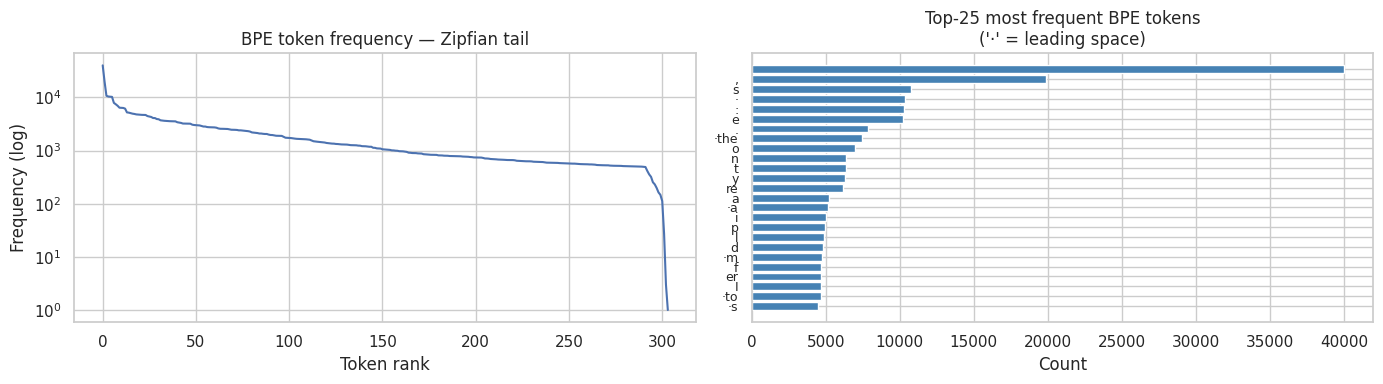

Saved: fig_bpe_distribution.png


In [4]:
counts = Counter(full_ids)
freq_sorted = sorted(counts.values(), reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(freq_sorted)
axes[0].set_yscale("log")
axes[0].set_xlabel("Token rank")
axes[0].set_ylabel("Frequency (log)")
axes[0].set_title("BPE token frequency — Zipfian tail")

top25 = counts.most_common(25)
top25_labels = [tokenizer.decode([tid]).replace(" ", "·") or f"<{tid}>" for tid, _ in top25]
top25_counts = [c for _, c in top25]
axes[1].barh(range(25), top25_counts[::-1], color="steelblue")
axes[1].set_yticks(range(25))
axes[1].set_yticklabels(top25_labels[::-1], fontsize=9)
axes[1].set_xlabel("Count")
axes[1].set_title("Top-25 most frequent BPE tokens\n('·' = leading space)")

plt.tight_layout()
plt.savefig("fig_bpe_distribution.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: fig_bpe_distribution.png")


In [5]:
SEQ_LEN = 50
STRIDE  = 8

sequences = []
for i in range(0, len(full_ids) - SEQ_LEN - 1, STRIDE):
    sequences.append(full_ids[i : i + SEQ_LEN + 1])

sequences = np.array(sequences, dtype=np.int64)
print(f"Total sequences: {len(sequences):,}")
print(f"Shape:           {sequences.shape}   (each row has SEQ_LEN+1 ids)")

# 80 / 20 split
split = int(0.8 * len(sequences))
train_seqs = sequences[:split]
val_seqs   = sequences[split:]
print(f"Train: {len(train_seqs):,}   Val: {len(val_seqs):,}")


Total sequences: 72,863
Shape:           (72863, 51)   (each row has SEQ_LEN+1 ids)
Train: 58,290   Val: 14,573


In [6]:
class ShakespeareDataset(Dataset):
    def __init__(self, seqs):
        self.seqs = torch.from_numpy(seqs)
    def __len__(self):
        return len(self.seqs)
    def __getitem__(self, idx):
        row = self.seqs[idx]
        return row[:-1], row[1:]

BATCH_SIZE = 64
train_ds = ShakespeareDataset(train_seqs)
val_ds   = ShakespeareDataset(val_seqs)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

x_demo, y_demo = next(iter(train_loader))
print(f"Batch shapes — input: {tuple(x_demo.shape)}  target: {tuple(y_demo.shape)}")
print(f"Input [0, :10] : {x_demo[0, :10].tolist()}")
print(f"Target[0, :10] : {y_demo[0, :10].tolist()}   <- shifted by 1")


Batch shapes — input: (64, 50)  target: (64, 50)
Input [0, :10] : [341, 321, 30, 358, 344, 325, 310, 284, 389, 72]
Target[0, :10] : [321, 30, 358, 344, 325, 310, 284, 389, 72, 271]   <- shifted by 1


In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, : x.size(1)]


In [8]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, attn_dropout: float = 0.0):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must divide evenly by n_heads"
        self.d_model  = d_model
        self.n_heads  = n_heads
        self.head_dim = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)
        self.attn_drop = nn.Dropout(attn_dropout)

    def forward(self, x):
        B, T, C = x.shape
        Q = self.W_q(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        scores = (Q @ K.transpose(-2, -1)) * (self.head_dim ** -0.5)

        causal = torch.triu(
            torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1
        )
        scores = scores.masked_fill(causal, float("-inf"))

        attn = F.softmax(scores, dim=-1)
        attn = self.attn_drop(attn)

        out = attn @ V
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(out), attn


In [9]:
class RMSNorm(nn.Module):
    def __init__(self, d_model: int, eps: float = 1e-8):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(d_model))
        self.eps = eps

    def forward(self, x):
        norm = x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
        return self.scale * norm


class TransformerBlock(nn.Module):
    def __init__(self, d_model: int, n_heads: int, ffn_dim: int, dropout: float = 0.1):
        super().__init__()
        self.norm1 = RMSNorm(d_model)
        self.attn  = CausalSelfAttention(d_model, n_heads, attn_dropout=dropout)
        self.norm2 = RMSNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ffn_dim),
            nn.GELU(),
            nn.Linear(ffn_dim, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        attn_out, attn_weights = self.attn(self.norm1(x))
        x = x + attn_out
        x = x + self.ffn(self.norm2(x))
        return x, attn_weights


### 2.4 Full Tiny Transformer

Hyperparameters follow the assignment recommendation: `d_model=128, n_heads=4, n_layers=2, ffn_dim=256`.


In [10]:
class TinyTransformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model:   int  = 128,
        n_heads:   int  = 4,
        n_layers:  int  = 2,
        ffn_dim:   int  = 256,
        max_len:   int  = 128,
        dropout:   float = 0.1,
        use_pos_enc: bool = True,
    ):
        super().__init__()
        self.use_pos_enc = use_pos_enc
        self.token_embed = nn.Embedding(vocab_size, d_model)
        self.pos_enc     = PositionalEncoding(d_model, max_len=max_len)
        self.drop_in     = nn.Dropout(dropout)
        self.blocks      = nn.ModuleList(
            [TransformerBlock(d_model, n_heads, ffn_dim, dropout) for _ in range(n_layers)]
        )
        self.final_norm  = RMSNorm(d_model)
        self.lm_head     = nn.Linear(d_model, vocab_size, bias=False)

        self.lm_head.weight = self.token_embed.weight

        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, x, return_attn: bool = False):
        h = self.token_embed(x)
        if self.use_pos_enc:
            h = self.pos_enc(h)
        h = self.drop_in(h)

        attn_maps = []
        for block in self.blocks:
            h, attn = block(h)
            if return_attn:
                attn_maps.append(attn)
        h = self.final_norm(h)
        logits = self.lm_head(h)
        return (logits, attn_maps) if return_attn else (logits, None)

model = TinyTransformer(vocab_size=actual_vocab).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}  (~{n_params/1e6:.2f}M)")

with torch.no_grad():
    xb, yb = next(iter(train_loader))
    xb = xb.to(device)
    logits, attn = model(xb, return_attn=True)
    print(f"Logits:         {tuple(logits.shape)}")
    print(f"Attention maps: {len(attn)} layers, each {tuple(attn[0].shape)}")


Model parameters: 327,552  (~0.33M)
Logits:         (64, 50, 500)
Attention maps: 2 layers, each (64, 4, 50, 50)


In [11]:
def evaluate(model, loader, vocab_size):
    model.eval()
    total_loss, total_tokens = 0.0, 0
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits, _ = model(x)
            loss = F.cross_entropy(
                logits.reshape(-1, vocab_size), y.reshape(-1), reduction="sum"
            )
            total_loss   += loss.item()
            total_tokens += y.numel()
            correct      += (logits.argmax(-1) == y).sum().item()
            total        += y.numel()
    avg_loss = total_loss / total_tokens
    return avg_loss, math.exp(avg_loss), correct / total


def capture_attention(model, loader, n_samples: int = 1):
    """Grab one validation batch's attention maps for later viz."""
    model.eval()
    with torch.no_grad():
        x, _ = next(iter(loader))
        x = x[:n_samples].to(device)
        _, attn_maps = model(x, return_attn=True)
    return x.cpu(), [a.cpu() for a in attn_maps]


In [12]:
EPOCHS    = 45
LR        = 3e-4
WD        = 0.01
SNAPSHOT_EPOCHS = [1, EPOCHS // 2, EPOCHS]

model = TinyTransformer(vocab_size=actual_vocab, max_len=SEQ_LEN + 8).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {
    "train_loss": [], "val_loss": [], "val_ppl": [],
    "val_acc": [],    "lr": [],       "grad_norm": [],
}
attention_snapshots = {}

start = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, running_tokens = 0.0, 0
    running_grad = 0.0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        logits, _ = model(x)
        loss = F.cross_entropy(logits.reshape(-1, actual_vocab), y.reshape(-1))

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss   += loss.item() * y.numel()
        running_tokens += y.numel()
        running_grad   += float(grad_norm)

    train_loss = running_loss / running_tokens
    val_loss, val_ppl, val_acc = evaluate(model, val_loader, actual_vocab)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_ppl"].append(val_ppl)
    history["val_acc"].append(val_acc)
    history["lr"].append(optimizer.param_groups[0]["lr"])
    history["grad_norm"].append(running_grad / len(train_loader))

    if epoch in SNAPSHOT_EPOCHS:
        attention_snapshots[epoch] = capture_attention(model, val_loader, n_samples=1)

    scheduler.step()
    print(
        f"Epoch {epoch:2d}/{EPOCHS} | "
        f"train loss {train_loss:.4f} | "
        f"val loss {val_loss:.4f} | val PPL {val_ppl:6.2f} | "
        f"tok-acc {val_acc:.3f} | "
        f"lr {history['lr'][-1]:.2e}"
    )

print(f"\nTraining wall-time: {(time.time()-start)/60:.1f} min")
print(f"Final val PPL: {history['val_ppl'][-1]:.2f}")


Epoch  1/45 | train loss 5.0492 | val loss 4.4167 | val PPL  82.82 | tok-acc 0.119 | lr 3.00e-04
Epoch  2/45 | train loss 4.2717 | val loss 4.0767 | val PPL  58.95 | tok-acc 0.136 | lr 3.00e-04
Epoch  3/45 | train loss 3.9858 | val loss 3.8865 | val PPL  48.74 | tok-acc 0.151 | lr 2.99e-04
Epoch  4/45 | train loss 3.7691 | val loss 3.7291 | val PPL  41.64 | tok-acc 0.172 | lr 2.97e-04
Epoch  5/45 | train loss 3.6112 | val loss 3.6212 | val PPL  37.38 | tok-acc 0.194 | lr 2.94e-04
Epoch  6/45 | train loss 3.4929 | val loss 3.5407 | val PPL  34.49 | tok-acc 0.207 | lr 2.91e-04
Epoch  7/45 | train loss 3.4002 | val loss 3.4925 | val PPL  32.87 | tok-acc 0.218 | lr 2.87e-04
Epoch  8/45 | train loss 3.3239 | val loss 3.4354 | val PPL  31.04 | tok-acc 0.230 | lr 2.82e-04
Epoch  9/45 | train loss 3.2595 | val loss 3.4033 | val PPL  30.06 | tok-acc 0.237 | lr 2.77e-04
Epoch 10/45 | train loss 3.2051 | val loss 3.3729 | val PPL  29.16 | tok-acc 0.247 | lr 2.71e-04
Epoch 11/45 | train loss 3.159

In [13]:
@torch.no_grad()
def generate(model, tokenizer, prompt: str, max_new: int = 200,
             temperature: float = 0.9, top_k: int = 40):
    model.eval()
    ids = tokenizer.encode(prompt).ids
    ids = torch.tensor([ids], dtype=torch.long, device=device)

    for _ in range(max_new):
        ids_cond = ids[:, -SEQ_LEN:]
        logits, _ = model(ids_cond)
        logits = logits[:, -1, :] / temperature
        if top_k is not None:
            v, _ = torch.topk(logits, top_k)
            logits[logits < v[:, [-1]]] = -float("inf")
        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        ids = torch.cat([ids, next_id], dim=1)
    return tokenizer.decode(ids[0].tolist())


print("=" * 72)
print("SAMPLE 1 — prompt: 'ROMEO:'")
print("=" * 72)
print(generate(model, tokenizer, "ROMEO:", max_new=180))

print("\n" + "=" * 72)
print("SAMPLE 2 — prompt: 'To be, or not to be'")
print("=" * 72)
print(generate(model, tokenizer, "To be, or not to be", max_new=180))


SAMPLE 1 — prompt: 'ROMEO:'
ROMEO:
Ay, time you.

CORIOLANUS:
I did be gone out the wal of his villain,
And I'll not well a moved or excoldice.

CAPULET:
Hark you; even in the white or I have
man it not to be a vower point, to crown'd on;
The brother, or cannot on the king into brother.

BRUTUS:
He is nothing, well.

CLARENCE:
Will, my lords, thou dost not follow'd: he, l

SAMPLE 2 — prompt: 'To be, or not to be'
To be, or not to be prosed of our agains.
What is the wilt thou know thyself?

KING HENRY VI

KING RICHARD II:
Brehe hath forman in this lack: and for these chalff;
He will not pretsent of the subjects.

DUKE OF AUMERLE:
O, though heavy book thy hopesty: I'll part
By exceion to tell thee take a collen about.

BUTUS:
Harry I do not he hath serviged,
To


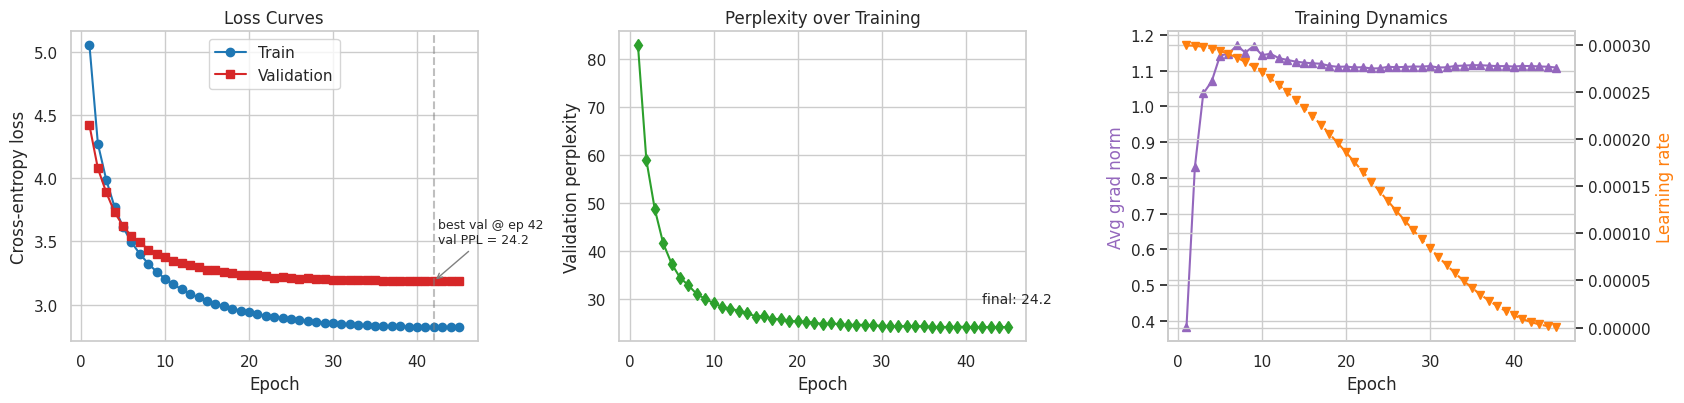


Final validation perplexity: 24.18
Best   validation perplexity: 24.16 @ epoch 42


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
epochs_axis = range(1, EPOCHS + 1)

axes[0].plot(epochs_axis, history["train_loss"], "o-", label="Train",      color="#1f77b4")
axes[0].plot(epochs_axis, history["val_loss"],   "s-", label="Validation", color="#d62728")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("Loss Curves"); axes[0].legend()
best = int(np.argmin(history["val_loss"]))
axes[0].axvline(best + 1, color="gray", linestyle="--", alpha=0.5)
axes[0].annotate(
    f"best val @ ep {best+1}\nval PPL = {history['val_ppl'][best]:.1f}",
    xy=(best + 1, history["val_loss"][best]),
    xytext=(best + 1 + 0.5, history["val_loss"][best] + 0.3),
    fontsize=9, arrowprops=dict(arrowstyle="->", color="gray"),
)

axes[1].plot(epochs_axis, history["val_ppl"], "d-", color="#2ca02c")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation perplexity")
axes[1].set_title("Perplexity over Training")
axes[1].annotate(
    f"final: {history['val_ppl'][-1]:.1f}",
    xy=(EPOCHS, history["val_ppl"][-1]),
    xytext=(EPOCHS - 3, history["val_ppl"][-1] + 5),
    fontsize=10,
)

axes[2].plot(epochs_axis, history["grad_norm"], "^-", color="#9467bd", label="Grad norm")
ax2 = axes[2].twinx()
ax2.plot(epochs_axis, history["lr"], "v--", color="#ff7f0e", label="LR")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Avg grad norm", color="#9467bd")
ax2.set_ylabel("Learning rate", color="#ff7f0e")
axes[2].set_title("Training Dynamics")

plt.tight_layout()
plt.savefig("fig_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nFinal validation perplexity: {history['val_ppl'][-1]:.2f}")
print(f"Best   validation perplexity: {min(history['val_ppl']):.2f} @ epoch {best+1}")


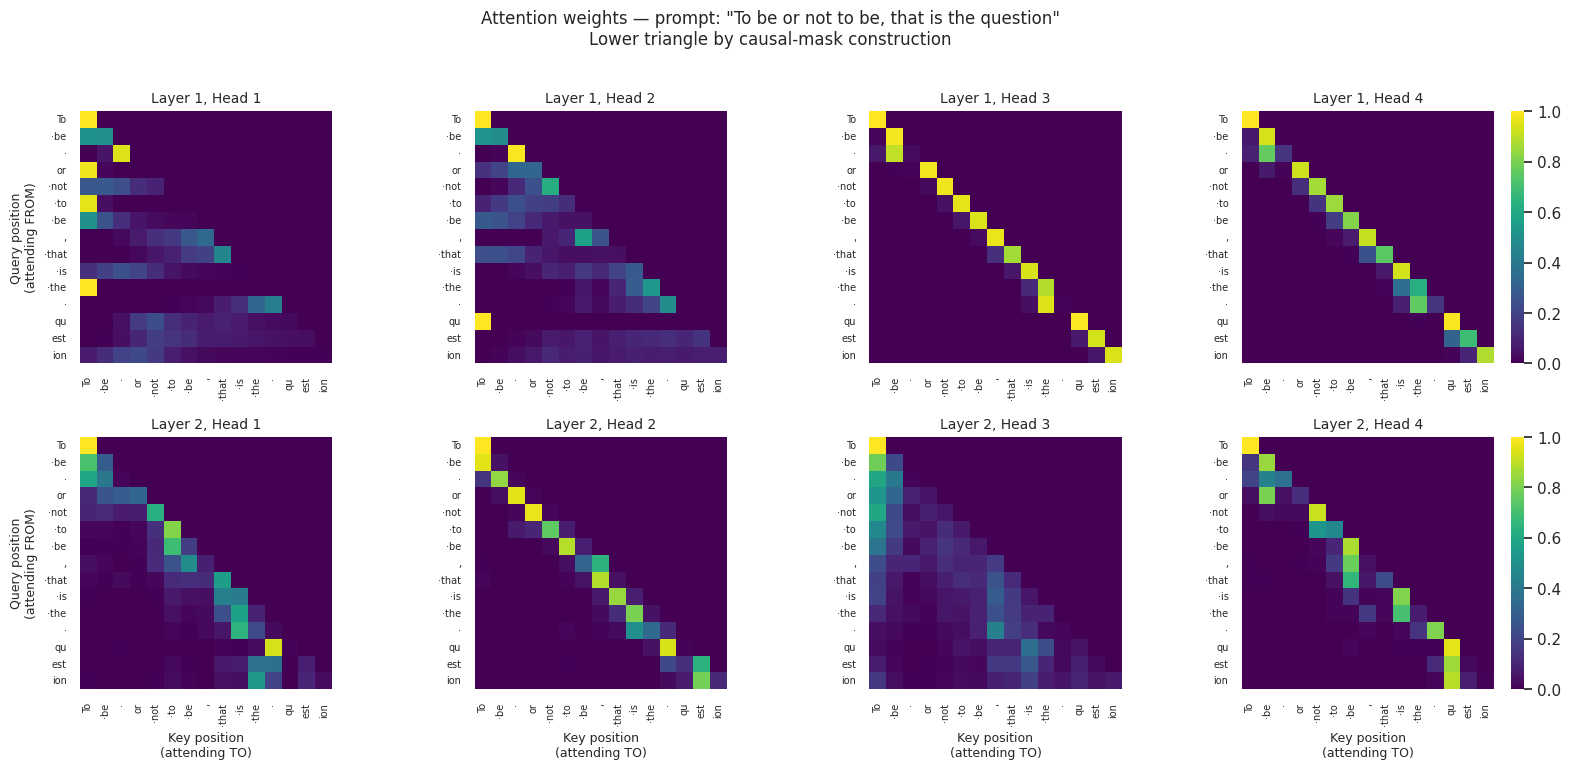

In [15]:
VIZ_PROMPT = "To be or not to be, that is the question"
viz_ids  = tokenizer.encode(VIZ_PROMPT).ids[:SEQ_LEN]
viz_tok  = [tokenizer.decode([i]).replace(" ", "·") for i in viz_ids]
viz_x    = torch.tensor([viz_ids], dtype=torch.long, device=device)

model.eval()
with torch.no_grad():
    _, viz_attn = model(viz_x, return_attn=True)

T_viz   = len(viz_ids)
N_LAYERS = len(viz_attn)
N_HEADS  = viz_attn[0].shape[1]

fig, axes = plt.subplots(N_LAYERS, N_HEADS, figsize=(4.1 * N_HEADS, 3.8 * N_LAYERS))
if N_LAYERS == 1:
    axes = axes[None, :]
if N_HEADS == 1:
    axes = axes[:, None]

for L in range(N_LAYERS):
    for H in range(N_HEADS):
        ax = axes[L][H]
        A  = viz_attn[L][0, H].cpu().numpy()[:T_viz, :T_viz]
        sns.heatmap(A, ax=ax, cmap="viridis", vmin=0, vmax=A.max(),
                    cbar=(H == N_HEADS - 1),
                    xticklabels=viz_tok, yticklabels=viz_tok,
                    square=True, linewidths=0)
        ax.set_title(f"Layer {L+1}, Head {H+1}", fontsize=10)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=7)
        if H == 0:
            ax.set_ylabel("Query position\n(attending FROM)", fontsize=9)
        if L == N_LAYERS - 1:
            ax.set_xlabel("Key position\n(attending TO)", fontsize=9)

plt.suptitle(
    f'Attention weights — prompt: "{VIZ_PROMPT}"\nLower triangle by causal-mask construction',
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.savefig("fig_attention_per_head.png", dpi=150, bbox_inches="tight")
plt.show()


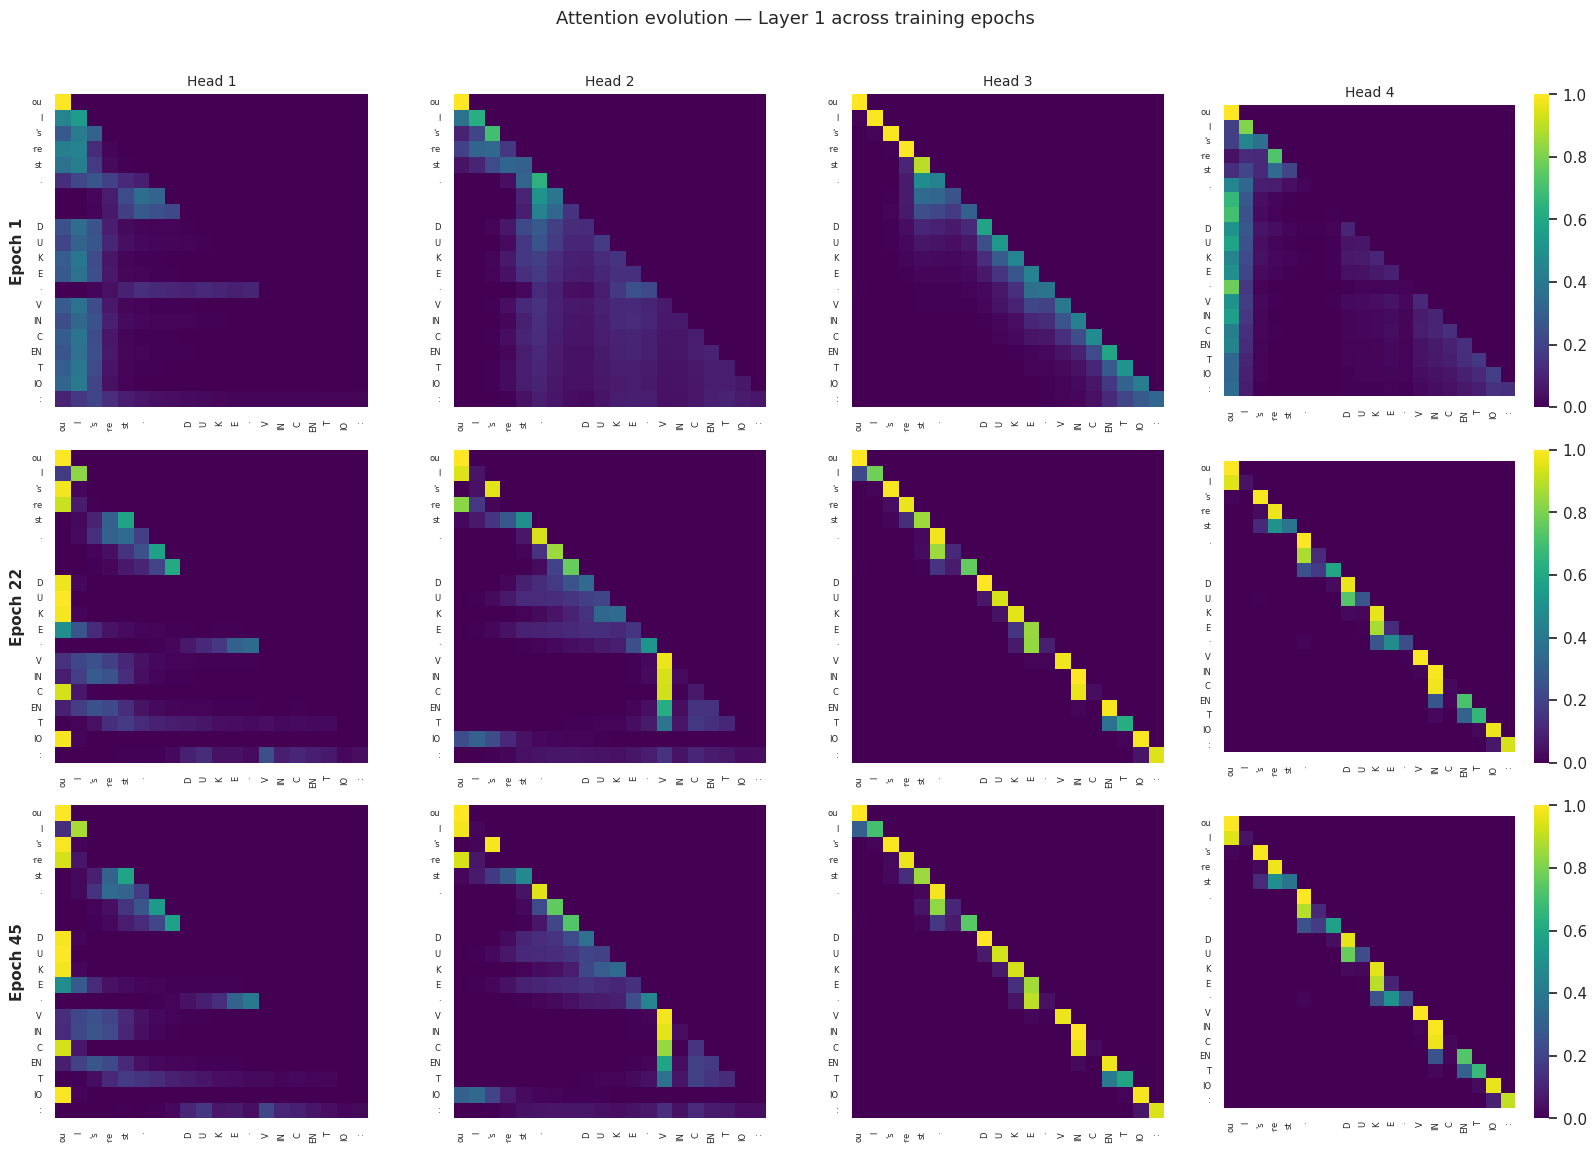

In [16]:
fig, axes = plt.subplots(len(SNAPSHOT_EPOCHS), N_HEADS, figsize=(4.1 * N_HEADS, 3.8 * len(SNAPSHOT_EPOCHS)))
if len(SNAPSHOT_EPOCHS) == 1:
    axes = axes[None, :]

LAYER_TO_TRACK = 0
for row, ep in enumerate(SNAPSHOT_EPOCHS):
    x_saved, attn_saved = attention_snapshots[ep]
    ids_ep = x_saved[0].tolist()
    T_ep   = min(20, len(ids_ep))
    labels = [tokenizer.decode([i]).replace(" ", "·") for i in ids_ep[:T_ep]]
    for H in range(N_HEADS):
        ax = axes[row][H]
        A  = attn_saved[LAYER_TO_TRACK][0, H].numpy()[:T_ep, :T_ep]
        sns.heatmap(A, ax=ax, cmap="viridis", vmin=0, vmax=A.max(),
                    cbar=(H == N_HEADS - 1),
                    xticklabels=labels, yticklabels=labels, square=True)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=6)
        if row == 0:
            ax.set_title(f"Head {H+1}", fontsize=10)
        if H == 0:
            ax.set_ylabel(f"Epoch {ep}", fontsize=11, fontweight="bold")

plt.suptitle(
    f"Attention evolution — Layer {LAYER_TO_TRACK+1} across training epochs",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.savefig("fig_attention_evolution.png", dpi=150, bbox_inches="tight")
plt.show()


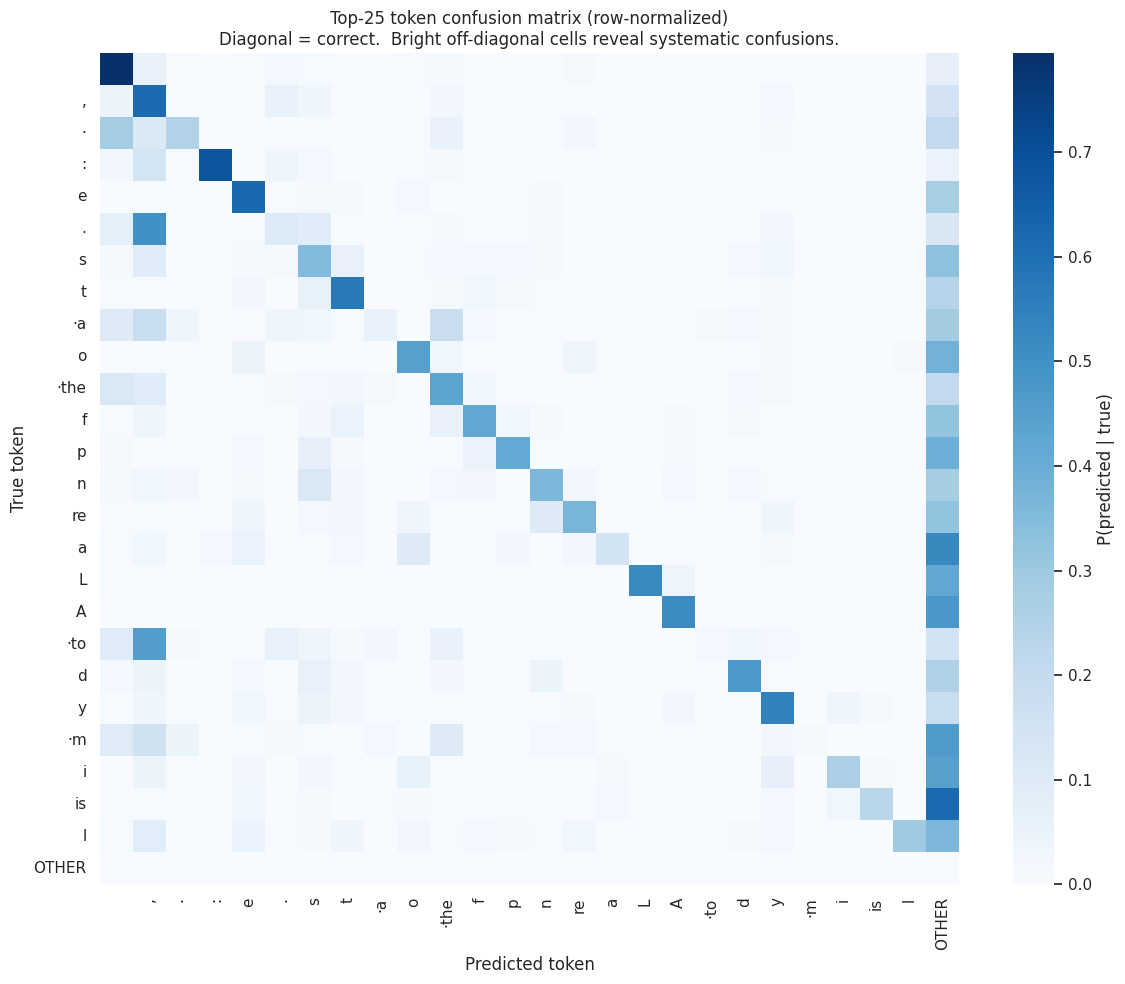

Mean diagonal accuracy across top-25 tokens: 0.381


In [17]:
from sklearn.metrics import confusion_matrix

@torch.no_grad()
def collect_preds(model, loader, max_batches=None):
    model.eval()
    all_pred, all_true = [], []
    for i, (x, y) in enumerate(loader):
        x, y = x.to(device), y.to(device)
        logits, _ = model(x)
        all_pred.append(logits.argmax(-1).reshape(-1).cpu().numpy())
        all_true.append(y.reshape(-1).cpu().numpy())
        if max_batches and i + 1 >= max_batches:
            break
    return np.concatenate(all_pred), np.concatenate(all_true)

preds, truths = collect_preds(model, val_loader, max_batches=30)

K_CONF = 25
top_tokens = [tid for tid, _ in Counter(truths.tolist()).most_common(K_CONF)]
mask = np.isin(truths, top_tokens)
p_masked, t_masked = preds[mask], truths[mask]

OTHER = -1
p_final = np.where(np.isin(p_masked, top_tokens), p_masked, OTHER)

labels_order = top_tokens + [OTHER]
tok_names = [tokenizer.decode([t]).replace(" ", "·") or f"<{t}>" for t in top_tokens] + ["OTHER"]

cm = confusion_matrix(t_masked, p_final, labels=labels_order)
cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_norm, annot=False, cmap="Blues", ax=ax,
            xticklabels=tok_names, yticklabels=tok_names[:-1] + ["OTHER"],
            cbar_kws={"label": "P(predicted | true)"})
ax.set_xlabel("Predicted token"); ax.set_ylabel("True token")
ax.set_title(f"Top-{K_CONF} token confusion matrix (row-normalized)\n"
             "Diagonal = correct.  Bright off-diagonal cells reveal systematic confusions.")
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("fig_confusion_topk.png", dpi=150, bbox_inches="tight")
plt.show()

diag_acc = np.diag(cm_norm[:-1, :-1]).mean()
print(f"Mean diagonal accuracy across top-{K_CONF} tokens: {diag_acc:.3f}")


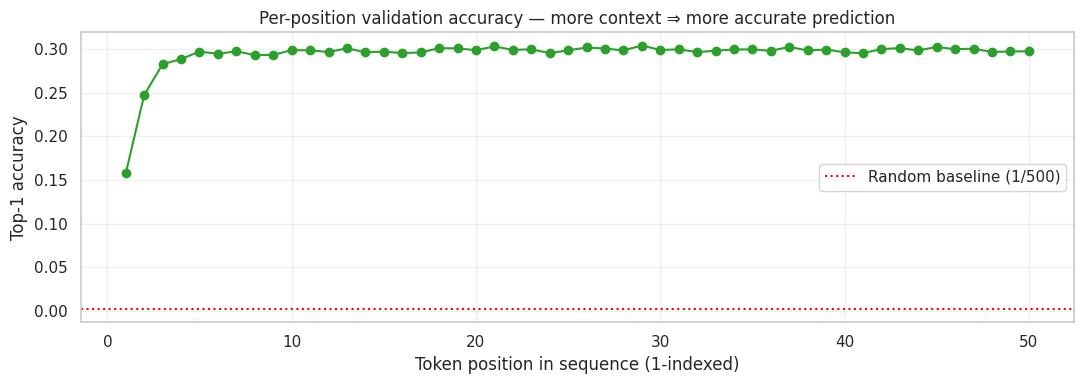

In [18]:
@torch.no_grad()
def per_position_accuracy(model, loader):
    model.eval()
    correct = torch.zeros(SEQ_LEN, dtype=torch.long)
    total   = torch.zeros(SEQ_LEN, dtype=torch.long)
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits, _ = model(x)
        pred = logits.argmax(-1)
        eq   = (pred == y).cpu()
        correct += eq.sum(dim=0)
        total   += torch.full((SEQ_LEN,), eq.size(0), dtype=torch.long)
    return (correct.float() / total.float()).numpy()

pos_acc = per_position_accuracy(model, val_loader)

plt.figure(figsize=(11, 4))
plt.plot(range(1, SEQ_LEN + 1), pos_acc, "o-", color="#2ca02c")
plt.axhline(1.0 / actual_vocab, linestyle=":", color="red",
            label=f"Random baseline (1/{actual_vocab})")
plt.xlabel("Token position in sequence (1-indexed)")
plt.ylabel("Top-1 accuracy")
plt.title("Per-position validation accuracy — more context ⇒ more accurate prediction")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_position_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()


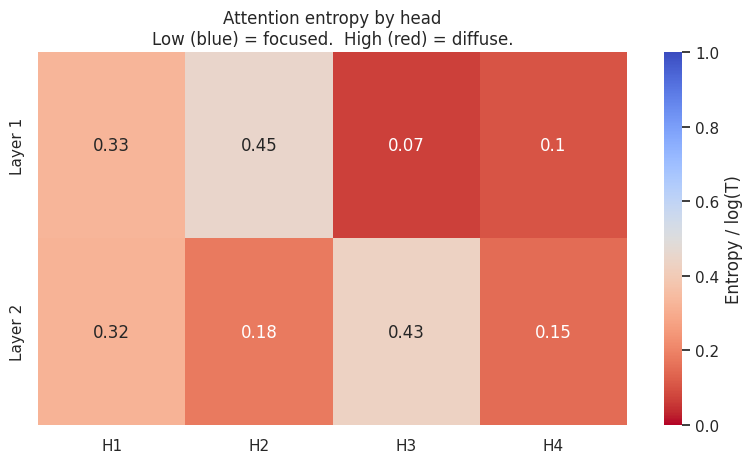

In [19]:
@torch.no_grad()
def head_entropy(model, loader, n_batches=5):
    model.eval()
    totals, counts = None, 0
    for i, (x, _) in enumerate(loader):
        x = x.to(device)
        _, attn = model(x, return_attn=True)
        batch_ent = []
        for A in attn:                                # (B, H, T, T)
            p = A.clamp_min(1e-12)
            e = -(p * p.log()).sum(dim=-1)            # (B, H, T)
            batch_ent.append(e.mean(dim=(0, 2)).cpu().numpy())  # (H,)
        batch_ent = np.stack(batch_ent)               # (L, H)
        totals = batch_ent if totals is None else totals + batch_ent
        counts += 1
        if counts >= n_batches:
            break
    return totals / counts

ent = head_entropy(model, val_loader)
max_ent = np.log(SEQ_LEN)
ent_norm = ent / max_ent

fig, ax = plt.subplots(figsize=(1.5 * N_HEADS + 2, 1.4 * N_LAYERS + 2))
sns.heatmap(ent_norm, annot=ent_norm.round(2), fmt="", cmap="coolwarm_r",
            vmin=0, vmax=1, cbar_kws={"label": "Entropy / log(T)"},
            xticklabels=[f"H{h+1}" for h in range(N_HEADS)],
            yticklabels=[f"Layer {l+1}" for l in range(N_LAYERS)], ax=ax)
ax.set_title("Attention entropy by head\nLow (blue) = focused.  High (red) = diffuse.")
plt.tight_layout()
plt.savefig("fig_head_entropy.png", dpi=150, bbox_inches="tight")
plt.show()


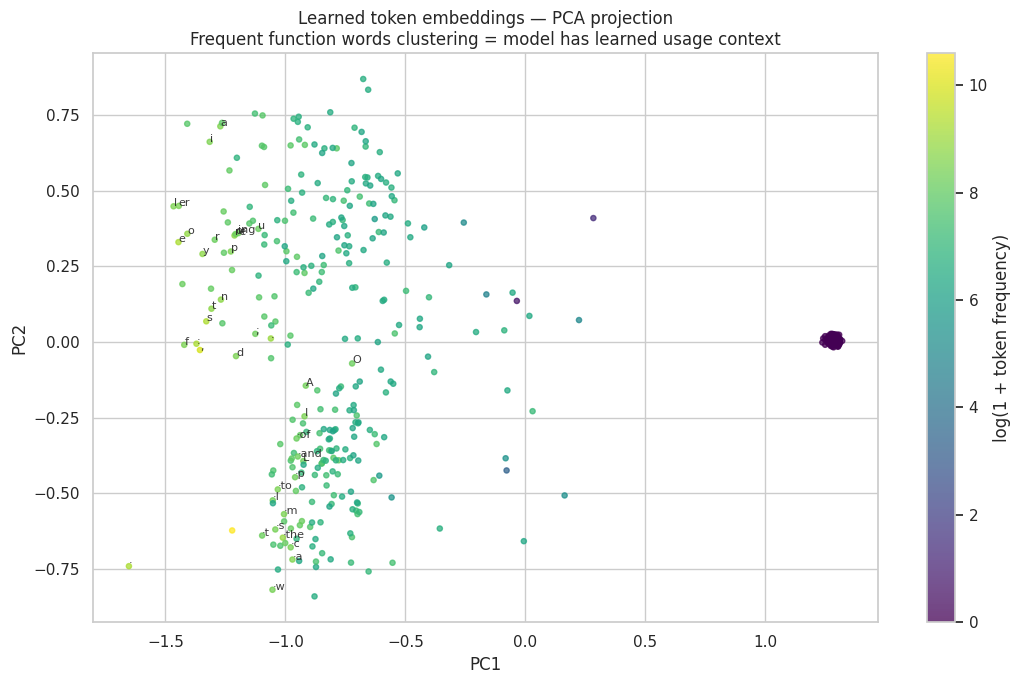

In [20]:
from sklearn.decomposition import PCA

emb = model.token_embed.weight.detach().cpu().numpy()
pca = PCA(n_components=2).fit_transform(emb)

log_freq = np.array([np.log1p(counts.get(i, 0)) for i in range(actual_vocab)])

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(pca[:, 0], pca[:, 1], c=log_freq, cmap="viridis", s=14, alpha=0.75)
plt.colorbar(sc, ax=ax, label="log(1 + token frequency)")

top_ids = [tid for tid, _ in counts.most_common(40)]
for tid in top_ids:
    lbl = tokenizer.decode([tid]).replace(" ", "·")
    if lbl.strip() == "":
        continue
    ax.annotate(lbl, (pca[tid, 0], pca[tid, 1]), fontsize=8, alpha=0.9)

ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Learned token embeddings — PCA projection\n"
             "Frequent function words clustering = model has learned usage context")
plt.tight_layout()
plt.savefig("fig_embedding_pca.png", dpi=150, bbox_inches="tight")
plt.show()


In [21]:
def run_short(model_kwargs, epochs=6, label=""):
    m = TinyTransformer(vocab_size=actual_vocab, max_len=SEQ_LEN + 8, **model_kwargs).to(device)
    opt = torch.optim.AdamW(m.parameters(), lr=LR, weight_decay=WD)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    val_ppls = []
    for ep in range(1, epochs + 1):
        m.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            logits, _ = m(x)
            loss = F.cross_entropy(logits.reshape(-1, actual_vocab), y.reshape(-1))
            opt.zero_grad(set_to_none=True); loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step()
        _, ppl, _ = evaluate(m, val_loader, actual_vocab)
        val_ppls.append(ppl)
        sch.step()
    print(f"[{label}] final val PPL = {val_ppls[-1]:.2f}")
    return val_ppls

ABLATION_EPOCHS = 6
abl_results = {}
abl_results["Baseline (w/ PE)"]   = run_short({"use_pos_enc": True},  ABLATION_EPOCHS, "baseline")
abl_results["No positional enc"]  = run_short({"use_pos_enc": False}, ABLATION_EPOCHS, "no-PE")
abl_results["1 layer"]            = run_short({"n_layers": 1},        ABLATION_EPOCHS, "1-layer")
abl_results["Bigger model (d=192)"] = run_short({"d_model": 192, "ffn_dim": 384}, ABLATION_EPOCHS, "d=192")


[baseline] final val PPL = 44.90
[no-PE] final val PPL = 29.52
[1-layer] final val PPL = 52.06
[d=192] final val PPL = 38.57


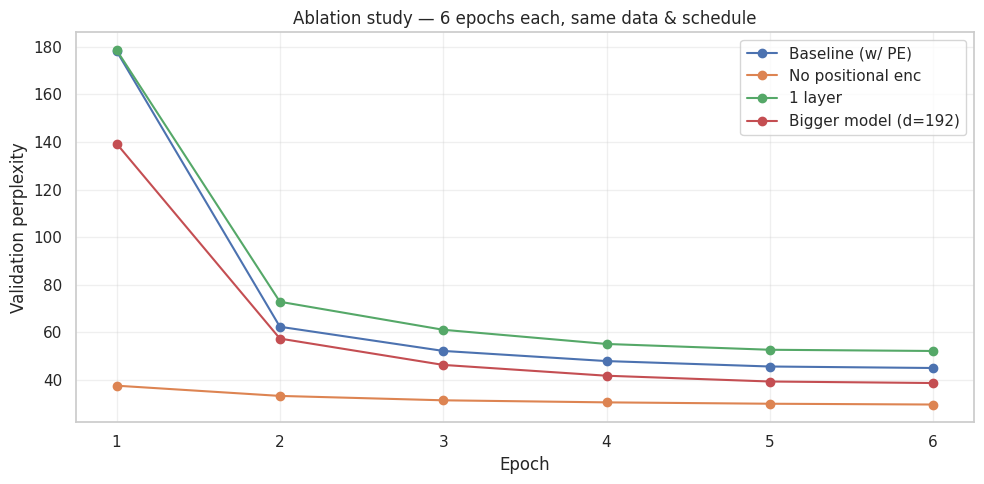


Final validation PPL summary
--------------------------------------------
  Baseline (w/ PE)              44.90
  No positional enc             29.52
  1 layer                       52.06
  Bigger model (d=192)          38.57


In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, ppls in abl_results.items():
    ax.plot(range(1, ABLATION_EPOCHS + 1), ppls, "o-", label=name)
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation perplexity")
ax.set_title(f"Ablation study — {ABLATION_EPOCHS} epochs each, same data & schedule")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nFinal validation PPL summary")
print("-" * 44)
for name, ppls in abl_results.items():
    print(f"  {name:<28s} {ppls[-1]:6.2f}")
